<a href="https://colab.research.google.com/github/Omar-RojasGBF/lis5693/blob/main/lab-8/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
%%capture
!pip install bertopic datasets openai datamapplot

In [ ]:
import requests
import io
import pandas as pd

url = "https://raw.githubusercontent.com/Omar-RojasGBF/lis5693/refs/heads/main/lab-5/lens-export.csv"
response = requests.get(url)
response.raise_for_status()

df = pd.read_csv(io.StringIO(response.text))

abstracts = list(df["Abstract"])
titles = list(df["Title"])

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedding_model = SentenceTransformer('thenlper/gte-small')


processed_abstracts = [str(x) if not (isinstance(x, float) and np.isnan(x)) else "" for x in abstracts]

embeddings = embedding_model.encode(processed_abstracts, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
embeddings.shape

(1000, 384)

In [ ]:
from umap import UMAP

umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

In [ ]:
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

len(set(clusters))

3

In [ ]:
import numpy as np

cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(processed_abstracts[index][:300] + "... \n")

... 

... 

... 



In [ ]:
import pandas as pd

reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

(np.float64(-14.299381732940674),
 np.float64(13.264788150787354),
 np.float64(-4.501782548427582),
 np.float64(9.943866145610809))

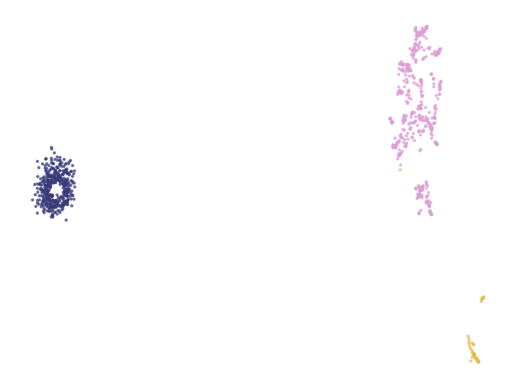

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')

In [ ]:
from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(processed_abstracts, embeddings)

2026-04-23 10:59:58,819 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-23 11:00:04,801 - BERTopic - Dimensionality - Completed ✓
2026-04-23 11:00:04,802 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-23 11:00:04,846 - BERTopic - Cluster - Completed ✓
2026-04-23 11:00:04,851 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-23 11:00:04,985 - BERTopic - Representation - Completed ✓


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,507,0_the_and_of_cancer,"[the, and, of, cancer, in, to, for, with, is, ...","[<AbstractText Label=""PURPOSE"" NlmCategory=""OB..."
1,1,425,1_his_he_the_to,"[his, he, the, to, and, mr, field, about, at, of]",[<jats:title>Abstract</jats:title><jats:p>Chem...
2,2,68,2_and_of_the_to,"[and, of, the, to, for, is, jats, on, suppleme...",[Data sharing is essential for reproducibility...


In [ ]:
topic_model.get_topic(0)

[('the', np.float64(0.1048884857872494)),
 ('and', np.float64(0.09757041288553946)),
 ('of', np.float64(0.09234046793850212)),
 ('cancer', np.float64(0.0822478389363178)),
 ('in', np.float64(0.08000446234177735)),
 ('to', np.float64(0.060484164119243795)),
 ('for', np.float64(0.044134851947383404)),
 ('with', np.float64(0.036232605672523004)),
 ('is', np.float64(0.029870693238655856)),
 ('were', np.float64(0.028741717631751092))]

In [ ]:
topic_model.find_topics("topic modeling")

([2, 1, 0],
 [np.float64(0.8702890703905466),
  np.float64(0.8357478295404548),
  np.float64(0.8338264076274395)])

In [ ]:
topic_model.get_topic(22)

False

In [ ]:
topic_model.topics_[titles.index('BERTopic: Neural topic modeling with a class-based TF-IDF procedure')]

ValueError: 'BERTopic: Neural topic modeling with a class-based TF-IDF procedure' is not in list

In [ ]:
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

fig.update_layout(font=dict(size=16))

In [ ]:
topic_model.visualize_barchart()

topic_model.visualize_heatmap(n_clusters=2)

topic_model.visualize_hierarchy()

For Lab 5, my code did not want to run at all. However, I was able to get it to run this time without any isues. I noticed a lot more words like "the" and "and" appearing this time than in Lab 5. This is most likely due to I cleaned my data in Lab 5 to prevent stop words and punctuation from appearing in ym results. I also feel like this lab's results were a smaller scale than lab 5's results. Since are clustering out text data, it might be natural for the final result to be smaller than the results of sentiment analysis. Trying to categorize opinions might feature a range of emotions/feelings than simply trying to cluster text data together.

Reflection 💭


---
I think my Google colab final works well again; I had major issues with running my code. I had to do some internet searching to know how to extract metadata from my csv file. I think I can see myself using large language models or embeddings right if libraries decide to integrate more AI models for search queries or recommondations.I recently attended a webinar over the integration of AI in libraries, and it really helped in thinking more creatively over how I can use what I learned in course in my future career.
